In [3]:
from pytket import Circuit
from pytket.extensions.qiskit import qiskit_to_tk, AerBackend
from pytket.circuit.display import render_circuit_jupyter
import numpy as np
from qiskit.circuit.library import QAOAAnsatz
from qiskit_optimization import QuadraticProgram

In [3]:
# create a QUBO
qubo = QuadraticProgram()
qubo.binary_var("x")
qubo.binary_var("y")
qubo.binary_var("z")
qubo.minimize(constant=2, linear=[1, -2, 3], quadratic={("x", "y"): 1, ("x", "z"): -1, ("y", "z"): 2})
print(qubo.prettyprint())
small_op, small_offset = qubo.to_ising()

p = 5
qiskit_circuit = QAOAAnsatz(cost_operator=small_op, reps=p, flatten=True)
# circuit.save_matrix_product_state(label='before_measure_mps')
qiskit_circuit.measure_all()

Problem name: 

Minimize
  x*y - x*z + 2*y*z + x - 2*y + 3*z + 2

Subject to
  No constraints

  Binary variables (3)
    x y z



In [5]:
Q, offset, T, N = np.load('../../qubo_solvers/out/diploid/qubo_data_both2.syncasm1001.cropped.gfa_normalisation_32.npy', allow_pickle=True)


In [6]:
mod = QuadraticProgram("QUBO test")
mod.binary_var_list(Q.shape[0])
mod.minimize(constant=offset, linear=None, quadratic=Q)
op, offset = mod.to_ising()
p = 1
qiskit_circuit = QAOAAnsatz(cost_operator=op, reps=p, flatten=True)
# circuit.save_matrix_product_state(label='before_measure_mps')
qiskit_circuit.measure_all()

In [7]:
tket_circ = qiskit_to_tk(qiskit_circuit)

# render_circuit_jupyter(tket_circ)

In [8]:
from jax import numpy as jnp, random, value_and_grad, jit
from sympy import Symbol
import matplotlib.pyplot as plt
import qujax
from pytket.extensions.qujax import tk_to_qujax

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [9]:
from qiskit.quantum_info import Pauli, SparsePauliOp
def pauli_exp(pauli: Pauli, coeff, circuit: Circuit):
    pauli_str = np.array(list(pauli.to_label()))
    if any(op not in ['I', 'Z'] for op in pauli_str):
        raise Exception("Only expecting Z type operators")
    acting_qubits = np.nonzero(pauli_str == 'Z')[0]
    if len(acting_qubits) == 2:
        circuit.CX(acting_qubits[0], acting_qubits[1])
        circuit.Rz(coeff, acting_qubits[1])
        circuit.CX(acting_qubits[0], acting_qubits[1])
    elif len(acting_qubits) == 1:
        circuit.Rz(coeff, acting_qubits[0]) # Factor of 2 here??
    elif len(acting_qubits[0]) == 0:
        pass
    else:
        raise Exception("Only expecting weight 2 Z operators")

In [10]:
op.num_qubits

54

In [11]:
def qaoa_circuit(hamiltonian: SparsePauliOp, depth):
    n_qubits = hamiltonian.num_qubits
    circuit = Circuit(n_qubits)
    p_keys = []

    # Initial State
    for i in range(n_qubits):
        circuit.H(i)
    for d in range(depth):
        # Hamiltonian unitary
        gamma_d = Symbol(f"γ_{d}")
        for index in range(len(hamiltonian)):
            pauli_op = hamiltonian.paulis[index]
            coef = hamiltonian.coeffs[index]
            pauli_exp(pauli_op, gamma_d * coef, circuit)
            circuit.add_barrier(range(0, n_qubits))
        p_keys.append(gamma_d)

        # Mixing unitary
        beta_d = Symbol(f"β_{d}")
        for i in range(n_qubits):
            circuit.Rx(beta_d, i)
        p_keys.append(beta_d)
    return circuit, p_keys

In [13]:
circuit, keys = qaoa_circuit(op, 1)
# render_circuit_jupyter(circuit)

In [14]:
symbol_map = {keys[i]: i for i in range(len(keys))}
param_to_statetensor = tk_to_qujax(circuit, symbol_map=symbol_map)

In [16]:
statetensor_to_expectation = qujax.get_statetensor_to_expectation_func(
    [['Z'] * len(np.nonzero(np.array(list(pauli.to_label())) == 'Z')[0]) for pauli in op.paulis], 
    [tuple(np.nonzero(np.array(list(pauli.to_label())) == 'Z')[0]) for pauli in op.paulis], 
    np.real(op.coeffs)
)

In [17]:
param_to_expectation = lambda param: statetensor_to_expectation(param_to_statetensor(param))

In [18]:
cost_and_grad = jit(value_and_grad(param_to_expectation))

In [19]:
seed = 123
key = random.PRNGKey(seed)
init_param = random.uniform(key, shape=(len(symbol_map),))

In [20]:
n_steps = 150
stepsize = 0.01
param = init_param
cost_vals = jnp.zeros(n_steps)
cost_vals = cost_vals.at[0].set(param_to_expectation(init_param))


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory allocating 144115188075855872 bytes.

In [75]:
for step in range(1, n_steps):
    cost_val, cost_grad = cost_and_grad(param)
    cost_vals = cost_vals.at[step].set(cost_val)
    param = param - stepsize * cost_grad
    print("Iteration:", step, "\tCost:", cost_val, end="\r")

Text(0, 0.5, 'Cost')

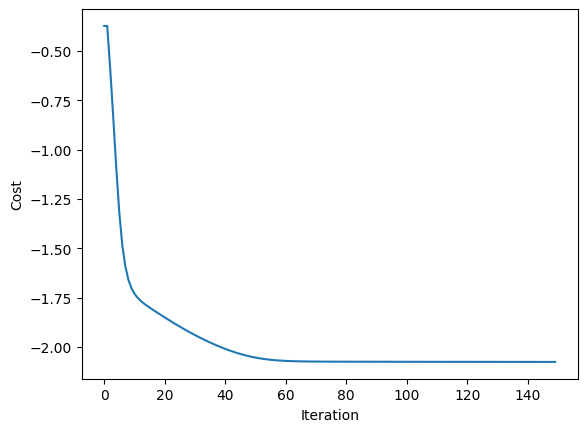

In [76]:
plt.plot(cost_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")